# Train dual-hose tracker (L, R) — folder: `dual_hose_tracker`

For L+R+T+B use `../quad_hose_tracker/`.


In [8]:
import pickle, sys, importlib
from pathlib import Path
import numpy as np
import keras
import matplotlib.pyplot as plt

sys.path.append('../../..')
sys.path.append('/home/wanglab/src/keras-unet-collection')
sys.path.append('/home/wanglab/Programs/tracking/DeepLearningUtils')
sys.path.append('/home/wanglab/Programs/tracking/DeepLearningUtils/src')

from keras_unet_collection import models
import hose_data
importlib.reload(hose_data)
from hose_data import create_hose_augmentation, dual_hose_loss, get_hose_generator_class, KEYPOINT_NAMES

HoseKeypointGenerator = get_hose_generator_class()
print('channels:', KEYPOINT_NAMES)


channels: ('hoseL', 'hoseR')


In [9]:
training_path = Path('/mnt/c/Users/wanglab/Desktop/pico-hose/')
checkpoint_path = 'unet_efficientnet_hose_lr_checkpoint.weights.h5'

num_classes = 2
input_shape = (256, 256, 3)
BATCH_SIZE = 16

augmentation = create_hose_augmentation()
pos_weight = 1000.0
channel_weights = (1.0, 1.0)
exclusivity_weight = 50.0
coactivation_weight = 10.0
freeze_backbone = True
learning_rate = 1e-4

train_pkl = training_path / 'training_data_hose_lr.pkl'
test_pkl = training_path / 'testing_data_hose_lr.pkl'
print('train pkl:', train_pkl, 'exists', train_pkl.exists())


train pkl: /mnt/c/Users/wanglab/Desktop/pico-hose/training_data_hose_lr.pkl exists True


In [10]:
(training_data, training_labels) = pickle.load(open(train_pkl, 'rb'))
(validation_data, validation_labels) = pickle.load(open(test_pkl, 'rb'))

def ensure_nhwc(images, labels):
    labels = np.asarray(labels)
    if labels.shape[1:3] == images.shape[1:3]:
        return labels
    if labels.shape[2:4] == images.shape[1:3]:
        return np.moveaxis(labels, 1, -1)
    raise ValueError(f'bad shapes {labels.shape} vs {images.shape}')

training_labels = ensure_nhwc(training_data, training_labels)
validation_labels = ensure_nhwc(validation_data, validation_labels)
assert training_labels.shape[-1] == 2, training_labels.shape

print(f'Train {training_data.shape} {training_labels.shape}')
print(f'Val   {validation_data.shape} {validation_labels.shape}')

training_generator = HoseKeypointGenerator(
    training_data, training_labels, augmentation=augmentation,
    batch_size=BATCH_SIZE, training=True,
)
validation_generator = HoseKeypointGenerator(
    validation_data, validation_labels, batch_size=BATCH_SIZE, training=False,
)
print('steps/epoch', len(training_generator))


Train (476, 256, 256, 3) (476, 256, 256, 2)
Val   (120, 256, 256, 3) (120, 256, 256, 2)
steps/epoch 29


In [11]:
filter_num = [64, 64, 64, 64, 64, 64]
base = models.att_unet_2d(
    input_shape, filter_num=filter_num, n_labels=num_classes,
    stack_num_down=2, stack_num_up=2, activation='ReLU', atten_activation='ReLU',
    attention='add', output_activation='Sigmoid', batch_norm=True, dropout=True,
    dropout_rate=0.1, l2_regularization=False, l2_weight=1e-4, pool=False, unpool=False,
    backbone='EfficientNetB1', weights='imagenet',
    freeze_backbone=freeze_backbone, freeze_batch_norm=freeze_backbone, name='attunet',
)
inputs = keras.Input(shape=input_shape)
x = keras.applications.efficientnet.preprocess_input(inputs)
model = keras.Model(inputs, base(x), name='dual_hose_tracker')
model.summary()


Model: "dual_hose_tracker"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attunet_model (Functional)      │ (None, 256, 256, 2)    │     8,579,021 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,579,021 (32.73 MB)

 Trainable params: 2,001,734 (7.64 MB)

 Non-trainable params: 6,577,287 (25.09 MB)

In [12]:
adamopt = keras.optimizers.AdamW(learning_rate=learning_rate)
cbs = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path), save_weights_only=True,
        monitor='val_loss', mode='min', save_best_only=True,
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss', mode='min', patience=20, restore_best_weights=True,
    ),
]
model.compile(
    optimizer=adamopt,
    loss=lambda yt, yp: dual_hose_loss(
        yt, yp, pos_weight=pos_weight, channel_weights=channel_weights,
        exclusivity_weight=exclusivity_weight, coactivation_weight=coactivation_weight,
    ),
)


In [13]:
r = model.fit(
    training_generator, epochs=150, validation_data=validation_generator, callbacks=cbs,
)
print(f"Trained {len(r.history['loss'])} epochs -> {checkpoint_path}")


Epoch 1/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 76s 623ms/step - loss: 0.1472 - val_loss: 0.1394
Epoch 2/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 258ms/step - loss: 0.1047 - val_loss: 0.0505
Epoch 3/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 258ms/step - loss: 0.0738 - val_loss: 0.0421
Epoch 4/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - loss: 0.0647 - val_loss: 0.0367
Epoch 5/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - loss: 0.0581 - val_loss: 0.0295
Epoch 6/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - loss: 0.0535 - val_loss: 0.0252
Epoch 7/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - loss: 0.0509 - val_loss: 0.0256
Epoch 8/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - loss: 0.0467 - val_loss: 0.0225
Epoch 9/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 250ms/step - loss: 0.0447 - val_loss: 0.0222
Epoch 10/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - loss: 0.0411 - val_loss: 0.0194
Epoch 11/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - loss: 0.0381 - val_loss: 0.0170
Epoch 12/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 

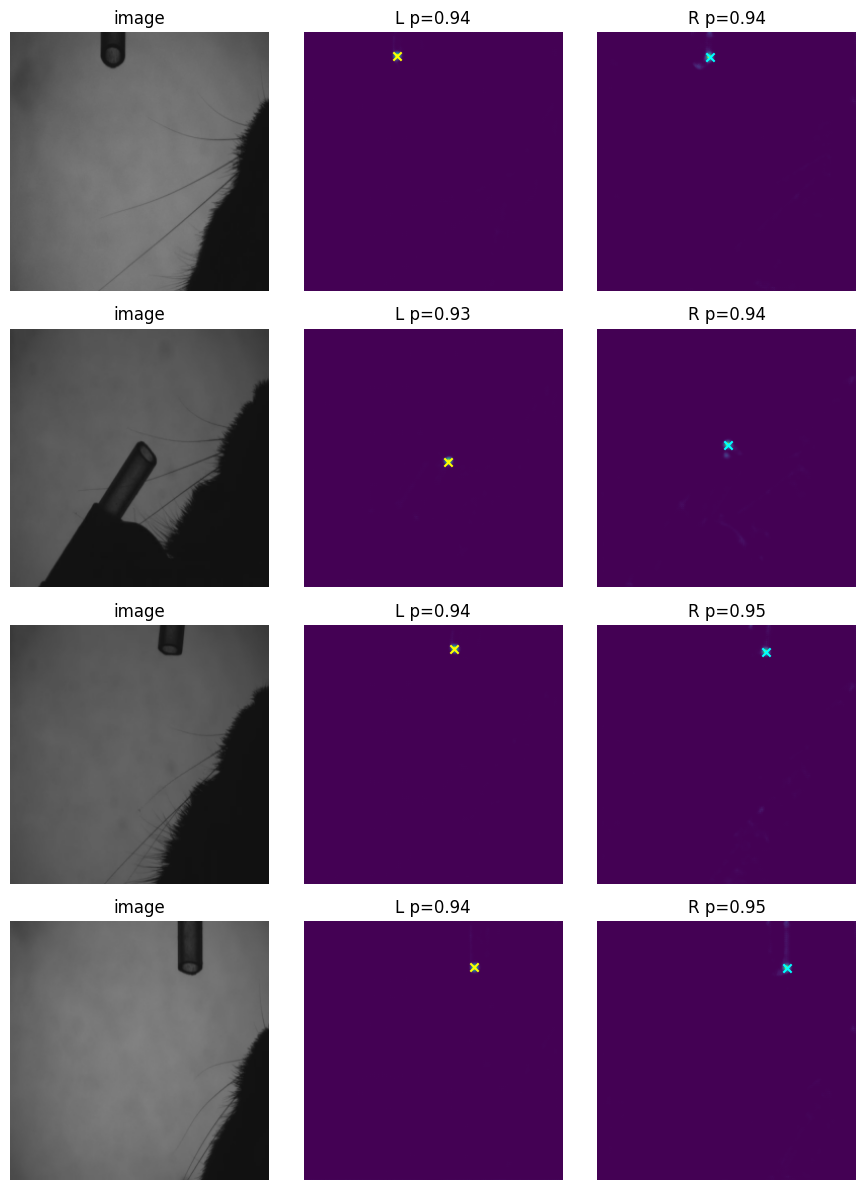

In [14]:
from hose_data import _extract_exclusive_peaks
has = np.any(validation_labels > 0, axis=(1, 2, 3))
idx = np.where(has)[0][:4]
xb = validation_data[idx].astype('float32')
yb = validation_labels[idx].astype('float32')
if yb.max() > 1: yb /= 255.0
pred = model.predict(xb, verbose=0)

fig, axes = plt.subplots(len(idx), 3, figsize=(9, 3*len(idx)))
for i in range(len(idx)):
    axes[i,0].imshow(validation_data[idx[i]][...,::-1]); axes[i,0].set_title('image'); axes[i,0].axis('off')
    left, right = _extract_exclusive_peaks(pred[i,...,0], pred[i,...,1])
    for c, (peak, name, col) in enumerate([(left,'L',1),(right,'R',2)]):
        axes[i,col].imshow(pred[i,...,c], vmin=0, vmax=max(0.1, float(pred[i,...,c].max())))
        axes[i,col].scatter(peak.y, peak.x, c='yellow' if c==0 else 'cyan', marker='x')
        axes[i,col].set_title(f'{name} p={peak.prob:.2f}'); axes[i,col].axis('off')
plt.tight_layout(); plt.show()
